In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/superstore_clean.csv", parse_dates=["Order Date", "Ship Date"])
df.info()

Matplotlib is building the font cache; this may take a moment.


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9800 non-null   int64         
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [2]:
yearly = df.groupby("Year")["Sales"].sum()
print(yearly)
print((yearly.pct_change() * 100).round(1))
print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False))
print(df.groupby("Region")["Sales"].sum().sort_values(ascending=False))

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64
Year
2015     NaN
2016    -4.3
2017    30.6
2018    20.3
Name: Sales, dtype: float64
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


## Key Insights

1. **Strong growth:** Sales rose from about $480K in 2015 to about $722K in 2018 (+50%), after a small dip of 4.3% in 2016. Growth was fastest in 2017 (+30.6%).
2. **Technology leads:** Technology generates about 37% of sales, but the three categories are close (Furniture 32%, Office Supplies 31%), so revenue is well diversified.
3. **Regional gap:** West (31%) and East (30%) drive over 60% of sales. South is the weakest at 17%, well under half of West's total.

## Recommendations

- Investigate why the South underperforms (fewer customers, weaker marketing, or logistics) and set a target to close part of the gap.
- Keep investing in Technology, the top category, while protecting the other two, since none is a minor line.
- Look at what drove the 2017-2018 growth and repeat it.

*Note: this dataset has no profit column, so "top" means highest revenue, not highest profitability.*

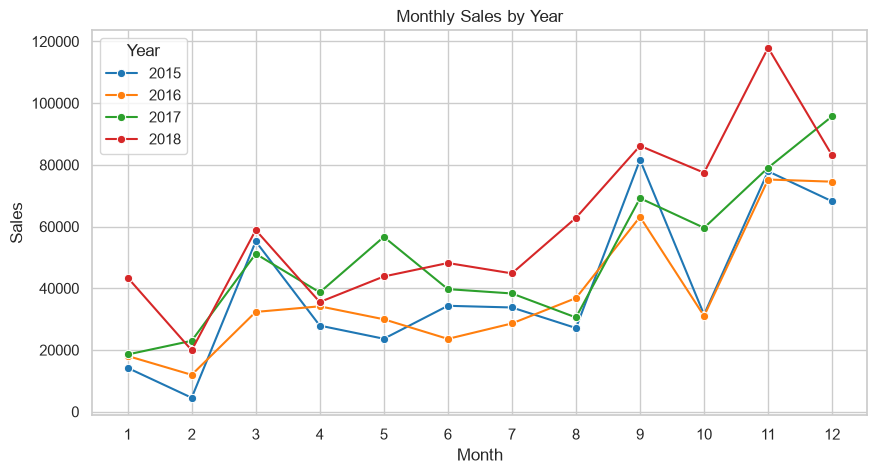

In [3]:
df["Month"] = df["Order Date"].dt.month
monthly = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x="Month", y="Sales", hue="Year", marker="o", palette="tab10")
plt.title("Monthly Sales by Year")
plt.xticks(range(1, 13))
plt.savefig("../images/monthly_sales.png", dpi=150, bbox_inches="tight")
plt.show()

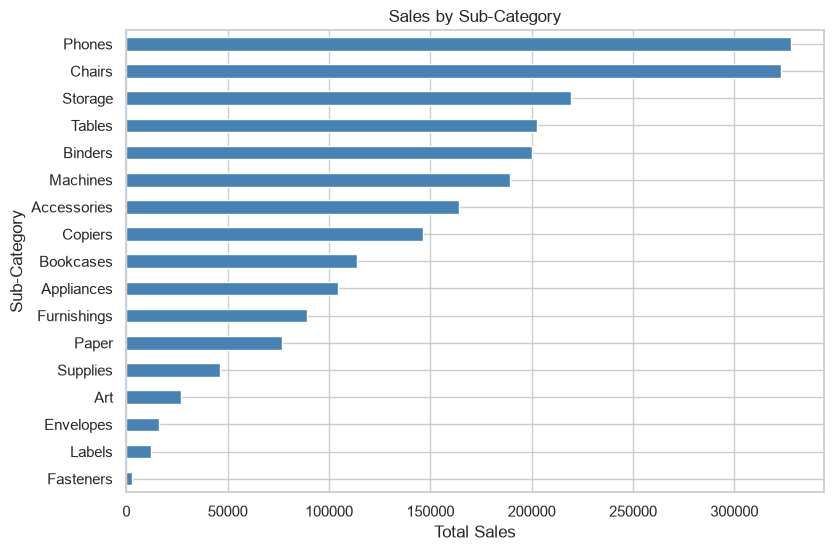

In [4]:
sub = df.groupby("Sub-Category")["Sales"].sum().sort_values()
plt.figure(figsize=(9, 6))
sub.plot(kind="barh", color="steelblue")
plt.title("Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.savefig("../images/sales_by_subcategory.png", dpi=150, bbox_inches="tight")
plt.show()

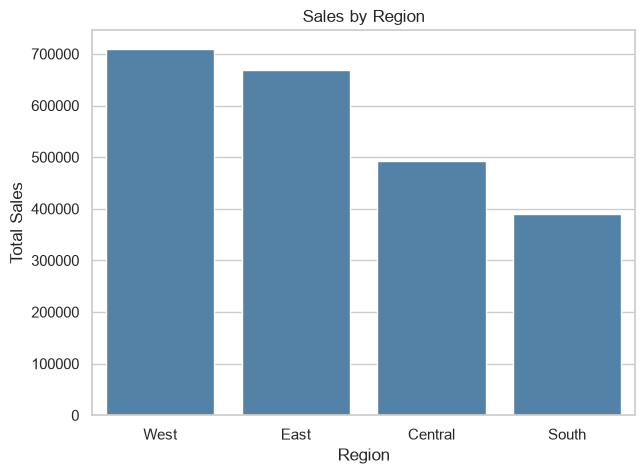

In [5]:
region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
sns.barplot(x=region.index, y=region.values, color="steelblue")
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.savefig("../images/sales_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

4. **Strong seasonality:** September, November, and December are the top three months in every year, together generating about 43% of annual sales. February is consistently the weakest month.